# Build 1 - The data layer, written from scratch

The notebooks numbered `01`-`06` in the parent folder *use* the finished package.
This series does the opposite: every function is written here, in the notebook,
before it exists anywhere else. By the end of this one you will have hand-built
the whole of `src/molecular_property_predictor/data.py` and understood why each
line is there.

**How to use this notebook.** Run it top to bottom. Each section states the
problem, you write (or read and run) the function that solves it, and the cell
immediately after checks it. The last section compares everything you built
against the shipped package, so you find out at once whether your version is
right.

**What the data layer has to do.** Four jobs, and they are separable:

| Job | Why it is not trivial |
| --- | --- |
| Get the raw data | 82 MB download that must not silently half-finish |
| Parse it | A bespoke text format written by Mathematica |
| Decide what to predict | Most of the 15 candidate targets are **traps** |
| Split it | Get this wrong and every later number is a lie |

The third one is the interesting one, and it is where most of this notebook goes.

In [1]:
from __future__ import annotations

import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd

# Anchor on the repository, not on the working directory. A notebook launched
# from notebooks/build/ and a test launched from the repo root must resolve
# data/ to the same place -- otherwise they quietly keep two copies of an
# 82 MB dataset and you debug the difference for an hour.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("project root :", PROJECT_ROOT)
print("raw data     :", RAW_DIR)
print("archive here :", (RAW_DIR / "dsgdb9nsd.xyz.tar.bz2").exists())

project root : C:\Users\rahul\OneDrive\Desktop\Project\molecular-property-predictor
raw data     : C:\Users\rahul\OneDrive\Desktop\Project\molecular-property-predictor\data\raw
archive here : True


## 1. Getting the data, without leaving a half-written file

The dataset is QM9 (Ramakrishnan et al., *Scientific Data* **1**, 140022, 2014):
133,885 small organic molecules of H, C, N, O, F with up to nine heavy atoms,
each with 15 properties computed at B3LYP/6-31G(2df,p) and a relaxed 3D geometry.

We read the **original published tarball**, not a preprocessed CSV mirror. That
costs us a parser and buys two things: the 3D coordinates (a SMILES-only mirror
throws them away, and every geometry-based representation needs them), and
provenance we can point at by DOI.

The one non-obvious detail in the downloader is the temporary filename.

In [2]:
QM9_XYZ_URL = "https://ndownloader.figshare.com/files/3195389"
QM9_UNCHARACTERIZED_URL = "https://ndownloader.figshare.com/files/3195404"


def download(url: str, destination: Path) -> Path:
    '''Download url to destination, skipping if it is already there.'''
    if destination.exists():
        return destination

    destination.parent.mkdir(parents=True, exist_ok=True)

    # Download to a temporary name, then rename. Writing straight to
    # `destination` means an interrupted download leaves a truncated file that
    # every later run treats as complete -- and a half-written 82 MB tarball
    # fails much further downstream than the place that actually broke.
    partial = destination.with_suffix(destination.suffix + ".partial")
    urllib.request.urlretrieve(url, partial)
    partial.replace(destination)
    return destination


archive = download(QM9_XYZ_URL, RAW_DIR / "dsgdb9nsd.xyz.tar.bz2")
print(f"{archive.name}: {archive.stat().st_size / 1e6:.1f} MB")

dsgdb9nsd.xyz.tar.bz2: 86.1 MB


## 2. What one molecule actually looks like

Before writing a parser, read the format. Here is the first file in the archive.

In [3]:
with tarfile.open(archive, "r:bz2") as tar:
    first = next(m for m in tar if m.name.endswith(".xyz"))
    raw_text = tar.extractfile(first).read().decode("utf-8")

print(first.name)
print("-" * 66)
for i, line in enumerate(raw_text.splitlines(), start=1):
    print(f"{i:>2} | {line}")

dsgdb9nsd_000001.xyz
------------------------------------------------------------------
 1 | 5
 2 | gdb 1	157.7118	157.70997	157.70699	0.	13.21	-0.3877	0.1171	0.5048	35.3641	0.044749	-40.47893	-40.476062	-40.475117	-40.498597	6.469	
 3 | C	-0.0126981359	 1.0858041578	 0.0080009958	-0.535689
 4 | H	 0.002150416	-0.0060313176	 0.0019761204	 0.133921
 5 | H	 1.0117308433	 1.4637511618	 0.0002765748	 0.133922
 6 | H	-0.540815069	 1.4475266138	-0.8766437152	 0.133923
 7 | H	-0.5238136345	 1.4379326443	 0.9063972942	 0.133923
 8 | 1341.307	1341.3284	1341.365	1562.6731	1562.7453	3038.3205	3151.6034	3151.6788	3151.7078
 9 | C	C	
10 | InChI=1S/CH4/h1H4	InChI=1S/CH4/h1H4


That is methane, and the layout is per the paper's Table 2:

| Line | Contents |
| --- | --- |
| 1 | number of atoms, `na` |
| 2 | the literal tag `gdb`, the molecule index, then the **15 properties** |
| 3 ... na+2 | element, x, y, z, Mulliken partial charge |
| na+3 | harmonic vibrational frequencies |
| na+4 | SMILES - from GDB-17, and from the relaxed geometry |
| na+5 | InChI - from both geometries |

Two traps are visible if you look closely:

1. **The two SMILES on line na+4.** They usually agree. The molecules where they
   *disagree* are exactly the ones the authors flagged as unreliable - we will
   use that in section 5.
2. **The number format.** Not in methane, but elsewhere in the archive you will
   find values like `1.234*^-6`. These files were generated with Mathematica,
   which writes exponents as `*^` where Python expects `e`. Feed that to
   `float()` and you get a `ValueError`.

Let's confirm trap 2 is real rather than taking my word for it.

In [4]:
print("float('1.234*^-6') ->", end=" ")
try:
    print(float("1.234*^-6"))
except ValueError as error:
    print(f"ValueError: {error}")

print("float('1.234e-6')  ->", float("1.234e-6"))

float('1.234*^-6') -> ValueError: could not convert string to float: '1.234*^-6'
float('1.234e-6')  -> 1.234e-06


So every numeric token needs normalising first. It is cheaper to normalise all of
them than to work out which columns are ever affected.

In [5]:
def parse_float(token: str) -> float:
    '''Parse one numeric token from a QM9 .xyz file.

    Mathematica writes exponents as 1.234*^-6 instead of the 1.234e-6 that
    float() understands. Only some columns are ever affected, but normalising
    every token is cheaper than guessing which.
    '''
    return float(token.replace("*^", "e"))


assert parse_float("1.234*^-6") == 1.234e-6
assert parse_float("-0.3877") == -0.3877
print("parse_float handles both notations")

parse_float handles both notations


## 3. Units: why anything gets converted at all

The 15 properties, in the order they appear on line 2:

In [6]:
PROPERTY_NAMES: tuple[str, ...] = (
    "A",      # GHz       rotational constant
    "B",      # GHz       rotational constant
    "C",      # GHz       rotational constant
    "mu",     # Debye     dipole moment
    "alpha",  # a0^3      isotropic polarizability
    "homo",   # Hartree   highest occupied molecular orbital energy
    "lumo",   # Hartree   lowest unoccupied molecular orbital energy
    "gap",    # Hartree   lumo - homo
    "r2",     # a0^2      electronic spatial extent
    "zpve",   # Hartree   zero point vibrational energy
    "U0",     # Hartree   internal energy at 0 K
    "U",      # Hartree   internal energy at 298.15 K
    "H",      # Hartree   enthalpy at 298.15 K
    "G",      # Hartree   free energy at 298.15 K
    "Cv",     # cal/mol/K heat capacity at 298.15 K
)

# CODATA 2018.
HARTREE_TO_EV = 27.211386245988

# The eight properties published in Hartree, which we convert on load.
HARTREE_PROPERTIES = frozenset({"homo", "lumo", "gap", "zpve", "U0", "U", "H", "G"})

ATOMIC_NUMBERS = {"H": 1, "C": 6, "N": 7, "O": 8, "F": 9}

print(f"{len(PROPERTY_NAMES)} properties, {len(HARTREE_PROPERTIES)} of them in Hartree")
print(f"1 Hartree = {HARTREE_TO_EV:.4f} eV")

15 properties, 8 of them in Hartree
1 Hartree = 27.2114 eV


**Why convert at all?** Nothing breaks if you keep Hartree. The reason is
comparability: the QM9 literature quotes errors in eV almost universally, so a
model reporting 0.0091 Hartree cannot be read against published numbers without
the reader doing arithmetic. Converting once, on load, means every error printed
anywhere in this project is already in the units a chemist expects.

Note also the discipline: convert **at the boundary**, never again. A quantity
that gets converted in two places will eventually get converted twice.

## 4. The parser

Now the whole thing. Note what it deliberately drops: the vibrational
frequencies. They are variable-length per molecule and nothing in this project
consumes them, so carrying them would be dead weight in every row.

In [7]:
def parse_xyz(text: str) -> dict:
    '''Parse a single QM9 .xyz file into a flat record.'''
    lines = text.splitlines()
    n_atoms = int(lines[0])

    header = lines[1].split()
    # header[0] is the literal tag "gdb"; header[1] is the molecule index.
    record: dict = {"index": int(header[1]), "n_atoms": n_atoms}

    # strict=True: if the header ever has a different number of properties than
    # PROPERTY_NAMES expects, fail here rather than silently mislabelling every
    # column after the mismatch.
    for name, token in zip(PROPERTY_NAMES, header[2:], strict=True):
        value = parse_float(token)
        record[name] = value * HARTREE_TO_EV if name in HARTREE_PROPERTIES else value

    elements: list[str] = []
    coordinates: list[float] = []
    charges: list[float] = []
    for line in lines[2 : 2 + n_atoms]:
        element, x, y, z, charge = line.split()
        elements.append(element)
        coordinates.extend((parse_float(x), parse_float(y), parse_float(z)))
        charges.append(parse_float(charge))

    record["elements"] = elements
    record["atomic_numbers"] = [ATOMIC_NUMBERS[e] for e in elements]
    # Flattened row-major. Parquet stores this as a list<double> column without
    # losing the nesting; reshape to (n_atoms, 3) when you need the geometry.
    record["coordinates"] = coordinates
    record["mulliken_charges"] = charges

    smiles = lines[2 + n_atoms + 1].split()
    record["smiles_gdb17"] = smiles[0]
    record["smiles_relaxed"] = smiles[-1]

    inchi = lines[2 + n_atoms + 2].split()
    record["inchi_gdb17"] = inchi[0]
    record["inchi_relaxed"] = inchi[-1]

    return record


methane = parse_xyz(raw_text)
for key, value in methane.items():
    print(f"  {key:<18} {str(value)[:60]}")

  index              1
  n_atoms            5
  A                  157.7118
  B                  157.70997
  C                  157.70699
  mu                 0.0
  alpha              13.21
  homo               -10.549854447569547
  lumo               3.1864533294051944
  gap                13.736307776974742
  r2                 35.3641
  zpve               1.2176823231217169
  U0                 -1101.487799054311
  U                  -1101.4097567985575
  H                  -1101.384042038555
  G                  -1102.0229653876108
  Cv                 6.469
  elements           ['C', 'H', 'H', 'H', 'H']
  atomic_numbers     [6, 1, 1, 1, 1]
  coordinates        [-0.0126981359, 1.0858041578, 0.0080009958, 0.002150416, -0.
  mulliken_charges   [-0.535689, 0.133921, 0.133922, 0.133923, 0.133923]
  smiles_gdb17       C
  smiles_relaxed     C
  inchi_gdb17        InChI=1S/CH4/h1H4
  inchi_relaxed      InChI=1S/CH4/h1H4


Check the conversion actually happened. Line 2 of the file gave `lumo = 0.1171`
in Hartree; the record should hold that number times 27.211.

In [8]:
expected_ev = 0.1171 * HARTREE_TO_EV
print("lumo in file   : 0.1171 Hartree")
print(f"lumo in record : {methane['lumo']:.6f} eV")
print(f"0.1171 * 27.21 : {expected_ev:.6f} eV")
assert np.isclose(methane["lumo"], expected_ev)

# And a property published in its own units is left alone.
print(f"\nCv in record   : {methane['Cv']} cal/mol/K  (unconverted, as published)")
assert methane["Cv"] == 6.469
print("\nunit handling is correct")

lumo in file   : 0.1171 Hartree
lumo in record : 3.186453 eV
0.1171 * 27.21 : 3.186453 eV

Cv in record   : 6.469 cal/mol/K  (unconverted, as published)

unit handling is correct


### Reshaping the geometry

Coordinates are stored flat so Parquet can hold them. Any geometry-based
representation wants `(n_atoms, 3)`, so that reshape gets its own function.

In [9]:
def geometry(row) -> tuple[np.ndarray, np.ndarray]:
    '''Return (atomic_numbers, coordinates) for one molecule.

    Coordinates come back shaped (n_atoms, 3) in Angstrom, which is the layout
    any geometry-based representation expects.
    '''
    atomic_numbers = np.asarray(row["atomic_numbers"], dtype=np.int64)
    coordinates = np.asarray(row["coordinates"], dtype=np.float64).reshape(-1, 3)
    return atomic_numbers, coordinates


z, xyz = geometry(methane)
print("atomic numbers:", z)
print("coordinates:")
print(xyz)
print("\nshape:", xyz.shape, "-- one row per atom, three columns")

atomic numbers: [6 1 1 1 1]
coordinates:
[[-1.26981359e-02  1.08580416e+00  8.00099580e-03]
 [ 2.15041600e-03 -6.03131760e-03  1.97612040e-03]
 [ 1.01173084e+00  1.46375116e+00  2.76574800e-04]
 [-5.40815069e-01  1.44752661e+00 -8.76643715e-01]
 [-5.23813634e-01  1.43793264e+00  9.06397294e-01]]

shape: (5, 3) -- one row per atom, three columns


## 5. The molecules to throw away

The authors published a file listing 3,054 molecules that failed a geometric
consistency check: the relaxed B3LYP geometry and the original Corina geometry
re-perceive to **different SMILES**. For those, the structure and the properties
describe different molecules.

Keeping them puts unlearnable rows in the training set and unanswerable rows in
the test set, so we drop them - visibly, not quietly.

The file is a human-readable report with a prose header, so the parser picks out
rows whose first token is an integer.

In [10]:
def load_uncharacterized(path: Path) -> set[int]:
    '''Read the indices of molecules that failed the consistency check.'''
    indices: set[int] = set()
    # encoding stated explicitly: read_text() otherwise defaults to the
    # platform's locale encoding, which is cp1252 on Windows and UTF-8
    # elsewhere. Letting it default makes the parse machine-dependent.
    for line in path.read_text(encoding="utf-8").splitlines():
        tokens = line.split()
        if tokens and tokens[0].isdigit():
            indices.add(int(tokens[0]))
    return indices


flagged_path = download(QM9_UNCHARACTERIZED_URL, RAW_DIR / "uncharacterized.txt")
print("--- first 12 lines of the raw file ---")
for line in flagged_path.read_text(encoding="utf-8").splitlines()[:12]:
    print("  ", line)

flagged = load_uncharacterized(flagged_path)
print(f"\nparsed {len(flagged):,} flagged indices")
print("published figure: 3,054")
assert len(flagged) == 3054

--- first 12 lines of the raw file ---
   
   List of molecules among the 133885 GDB9 molecules for which the Corina generated Cartesian coordinates and the B3LYP/6-31G(2df,p) equilibrium geometry lead to 
   different SMILES and InChI strings when parsed through the program Openbabel. Given are the indices of these molecules in the database, the original GDB17 
   SMILES, the SMILES generated from the Cartesian coordinates using Openbabel, as well as the L1 norm of the difference between the Coulomb matrices (D_IJ in au) 
   corresponding to the Corina and B3LYP coordinates.  
   
   #   Index                           GDB17 SMILES                         SMILES for B3LYP XYZ              SMILES for Corina generated XYZ              D_IJ
         58                               NC(=N)C#N                                    NC(=N)C#N                             [NH]C(=[NH2])C#N            6.036217
         61                               NC(=N)C=O                                    NC

## 6. Parsing the whole archive

The loop is unremarkable: walk the tar, parse each `.xyz`, build a DataFrame,
sort by molecule index, drop the flagged ones.

Two decisions worth stating:

- **Sort by index.** The tar does not guarantee member order. Row order has to be
  deterministic, because in section 8 the split is a seeded permutation *of row
  positions* - a different row order silently gives a different split.
- **Cache as Parquet, not CSV.** CSV cannot hold the variable-length coordinate
  arrays, and loses dtypes on every round trip.

Parsing all 133,885 files takes a couple of minutes, so the cell below parses a
**2,000-molecule subset** to show the loop running, then loads the full cached
Parquet for the analysis that follows.

In [11]:
import time


def parse_archive(archive: Path, limit: int | None = None) -> pd.DataFrame:
    '''Parse .xyz members from the tarball into a DataFrame.'''
    records = []
    with tarfile.open(archive, "r:bz2") as tar:
        for member in tar:
            if not member.name.endswith(".xyz"):
                continue
            handle = tar.extractfile(member)
            if handle is None:
                continue
            records.append(parse_xyz(handle.read().decode("utf-8")))
            if limit is not None and len(records) >= limit:
                break
    return pd.DataFrame.from_records(records).sort_values("index", ignore_index=True)


start = time.perf_counter()
subset = parse_archive(archive, limit=2000)
elapsed = time.perf_counter() - start

print(f"parsed {len(subset):,} molecules in {elapsed:.1f}s")
print(f"extrapolates to ~{elapsed * 133885 / 2000:.0f}s for the full archive")
print(f"\ncolumns: {list(subset.columns)}")
subset[["index", "n_atoms", "lumo", "smiles_relaxed"]].head()

parsed 2,000 molecules in 0.2s
extrapolates to ~14s for the full archive

columns: ['index', 'n_atoms', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'U0', 'U', 'H', 'G', 'Cv', 'elements', 'atomic_numbers', 'coordinates', 'mulliken_charges', 'smiles_gdb17', 'smiles_relaxed', 'inchi_gdb17', 'inchi_relaxed']


,index,n_atoms,lumo,smiles_relaxed
0,1,5,3.186453,C
1,2,4,2.255824,N
2,3,3,1.869422,O
3,4,4,1.376896,C#C
4,5,3,0.519737,C#N


In [12]:
def load_qm9(use_cache: bool = True) -> pd.DataFrame:
    '''Download (once), parse, cache, and return QM9 with flagged rows dropped.'''
    cache = PROCESSED_DIR / "qm9.parquet"
    if use_cache and cache.exists():
        return pd.read_parquet(cache)

    frame = parse_archive(download(QM9_XYZ_URL, RAW_DIR / "dsgdb9nsd.xyz.tar.bz2"))
    flagged = load_uncharacterized(
        download(QM9_UNCHARACTERIZED_URL, RAW_DIR / "uncharacterized.txt")
    )
    frame = frame[~frame["index"].isin(flagged)].reset_index(drop=True)

    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    frame.to_parquet(cache, index=False)
    return frame


df = load_qm9()
print("published        : 133,885")
print(f"flagged, dropped :   {len(flagged):,}")
print(f"remaining        : {len(df):,}")
assert len(df) == 133885 - 3054
print(f"\natoms per molecule: {df['n_atoms'].min()} to {df['n_atoms'].max()}")

published        : 133,885
flagged, dropped :   3,054
remaining        : 130,831

atoms per molecule: 3 to 29


## 7. Choosing the target - the most important cell in this notebook

There are 15 properties. Predicting any of them is a legitimate regression
problem, so which do we pick?

The instinct is "whichever gives the best R-squared." That instinct is exactly
wrong, and seeing why is the point of this section.

**The test.** Fit ordinary least squares on **atom counts alone** - five numbers
per molecule, `(n_H, n_C, n_N, n_O, n_F)`. That model knows no chemistry
whatsoever. It cannot tell a straight chain from a ring, an alcohol from an
ether. If a property is genuinely hard, this model should do badly on it.

So: run it against all 15, and look for the ones where it does *well*.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Five features: how many of each element. No geometry, no connectivity.
counts = np.zeros((len(df), 5), dtype=np.float64)
for position, numbers in enumerate(df["atomic_numbers"]):
    numbers = np.asarray(numbers)
    for column, element_z in enumerate(ATOMIC_NUMBERS.values()):
        counts[position, column] = np.count_nonzero(numbers == element_z)

print("atom-count features, first 3 molecules (H, C, N, O, F):")
print(counts[:3])

rows = []
for name in PROPERTY_NAMES:
    y = df[name].to_numpy(dtype=np.float64)
    fitted = LinearRegression().fit(counts, y)
    rows.append({
        "property": name,
        "r2_from_atom_counts": r2_score(y, fitted.predict(counts)),
        "mae_predicting_the_mean": float(np.mean(np.abs(y - y.mean()))),
    })

leakage = pd.DataFrame(rows).sort_values("r2_from_atom_counts", ascending=False)
print()
print(leakage.to_string(index=False, float_format=lambda v: f"{v:10.4f}"))

atom-count features, first 3 molecules (H, C, N, O, F):
[[4. 1. 0. 0. 0.]
 [3. 0. 1. 0. 0.]
 [2. 0. 0. 1. 0.]]



property  r2_from_atom_counts  mae_predicting_the_mean
       U               1.0000                 841.5287
       H               1.0000                 841.5287
      U0               1.0000                 841.5322
       G               1.0000                 841.5414
    zpve               0.9971                   0.7172
   alpha               0.8611                   6.2918
      Cv               0.7035                   3.2076
    lumo               0.4555                   1.0510
     gap               0.4016                   1.0742
      r2               0.3011                 202.5764
      mu               0.2214                   1.1691
    homo               0.0859                   0.4398
       C               0.0623                   0.2495
       B               0.0514                   0.3512
       A               0.0005                  13.1269


### Read that table carefully

Four properties - `U0`, `U`, `H`, `G` - sit at **R-squared = 1.0000**. A model
that only counts atoms explains essentially *all* of their variance.

That is not a lucky feature. It is physics: those are total energies, and a
molecule's total energy is dominated by the sum of its constituent atomic
energies. Predict them and you will publish a spectacular R-squared while having
learned nothing but a lookup table of atomic contributions. `zpve` at 0.9971 is
the same story.

**These targets leak.** They are the trap, and they are also among the most
commonly chosen QM9 targets in tutorial write-ups, which is why so many of those
report implausibly good numbers.

Now look at the other end of the table.

In [14]:
print(leakage.tail(6).to_string(index=False, float_format=lambda v: f"{v:10.4f}"))
print()
print("The chemistry-free model explains:")
for name in ("lumo", "homo", "gap"):
    r2 = float(leakage.loc[leakage["property"] == name, "r2_from_atom_counts"].iloc[0])
    print(f"  {name:<5} R2 = {r2:.4f}  -> {(1 - r2) * 100:.0f}% of variance still unexplained")

property  r2_from_atom_counts  mae_predicting_the_mean
      r2               0.3011                 202.5764
      mu               0.2214                   1.1691
    homo               0.0859                   0.4398
       C               0.0623                   0.2495
       B               0.0514                   0.3512
       A               0.0005                  13.1269

The chemistry-free model explains:
  lumo  R2 = 0.4555  -> 54% of variance still unexplained
  homo  R2 = 0.0859  -> 91% of variance still unexplained
  gap   R2 = 0.4016  -> 60% of variance still unexplained


`lumo` - the energy of the lowest unoccupied molecular orbital - is reachable
from atom counts only to R-squared around 0.46. More than half its variance
genuinely requires knowing the *structure*: which atoms are bonded to which, in
what geometry. That is a target where a geometry-based representation has
something to prove, and where beating the baseline means something.

So `lumo` it is. Recorded as a constant with the reasoning attached, not as a
number someone has to rediscover.

In [15]:
TARGET_PROPERTY = "lumo"

# The floor: mean absolute error of always predicting the mean. Any model that
# cannot beat this has contributed nothing at all.
y_target = df[TARGET_PROPERTY].to_numpy(dtype=np.float64)
TARGET_MEAN_BASELINE_MAE_EV = float(np.mean(np.abs(y_target - y_target.mean())))

print(f"target            : {TARGET_PROPERTY}")
print("units             : eV")
print(f"mean              : {y_target.mean():.4f} eV")
print(f"std               : {y_target.std():.4f} eV")
print(f"range             : {y_target.min():.3f} to {y_target.max():.3f} eV")
print(f"\nMAE of predicting the mean: {TARGET_MEAN_BASELINE_MAE_EV:.4f} eV")
print("^ this is the number every later model has to beat")

target            : lumo
units             : eV
mean              : 0.3220 eV
std               : 1.2749 eV
range             : -4.762 to 5.265 eV

MAE of predicting the mean: 1.0510 eV
^ this is the number every later model has to beat


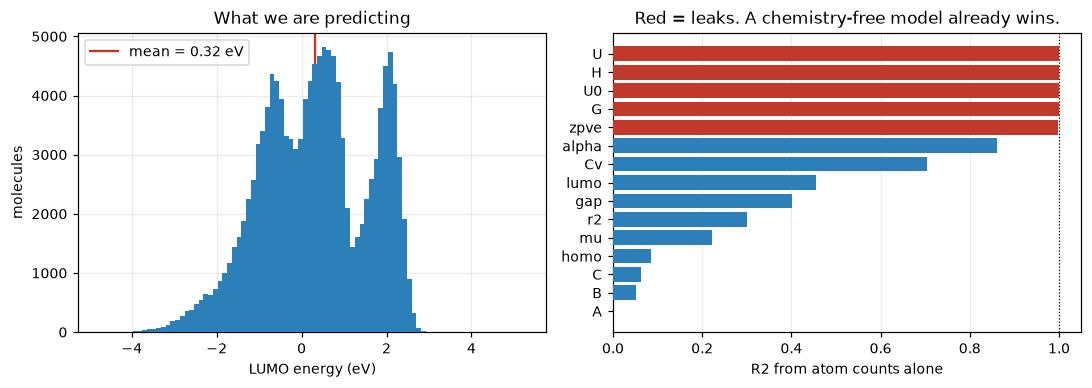

In [16]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.6))

left.hist(y_target, bins=90, color="#2c7fb8", zorder=3)
left.axvline(y_target.mean(), color="#c0392b", linewidth=1.5,
             label=f"mean = {y_target.mean():.2f} eV")
left.set_xlabel("LUMO energy (eV)")
left.set_ylabel("molecules")
left.set_title("What we are predicting")
left.legend()
left.grid(alpha=0.25, zorder=0)

order = leakage.sort_values("r2_from_atom_counts")
colours = ["#c0392b" if r > 0.99 else "#2c7fb8" for r in order["r2_from_atom_counts"]]
right.barh(order["property"], order["r2_from_atom_counts"], color=colours, zorder=3)
right.axvline(1.0, color="black", linewidth=0.8, linestyle=":")
right.set_xlabel("R2 from atom counts alone")
right.set_title("Red = leaks. A chemistry-free model already wins.")
right.grid(alpha=0.25, axis="x", zorder=0)

plt.tight_layout()
plt.show()

## 8. The split, from first principles

**Why three sets and not two.** Train fits the parameters. But the moment you
choose *anything* by looking at a set - learning rate, network width, when to
stop, which representation - that set stops being an unbiased estimate of
performance on unseen data, because your choices have been fitted to it.

So: **train** fits parameters, **validation** guides every choice we make, and
**test** is opened exactly once, at the very end, on one final model. Every score
in phases 3-5 of this project is a validation score for precisely this reason.

**Why a seed.** The same seed always yields the same partition, so a result from
the baseline phase stays comparable to one from the neural network phase. Without
it the two models are scored on different molecules and the comparison is noise.

In [17]:
def split_dataset(
    frame: pd.DataFrame,
    *,
    train_frac: float = 0.8,
    val_frac: float = 0.1,
    seed: int = 0,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    '''Split into train / validation / test by seeded random permutation.'''
    if not 0 < train_frac < 1 or not 0 < val_frac < 1:
        raise ValueError("train_frac and val_frac must each lie in (0, 1)")
    if train_frac + val_frac >= 1:
        raise ValueError(
            f"train_frac + val_frac must be < 1 to leave a test set, "
            f"got {train_frac} + {val_frac} = {train_frac + val_frac}"
        )

    permutation = np.random.default_rng(seed).permutation(len(frame))
    n_train = int(len(frame) * train_frac)
    n_val = int(len(frame) * val_frac)

    shuffled = frame.iloc[permutation].reset_index(drop=True)
    return (
        shuffled.iloc[:n_train].reset_index(drop=True),
        shuffled.iloc[n_train : n_train + n_val].reset_index(drop=True),
        shuffled.iloc[n_train + n_val :].reset_index(drop=True),
    )


train, validation, test = split_dataset(df)
for name, part in (("train", train), ("validation", validation), ("test", test)):
    print(f"{name:>11}: {len(part):>7,} ({len(part) / len(df):5.1%})")

      train: 104,664 (80.0%)
 validation:  13,083 (10.0%)
       test:  13,084 (10.0%)


Now *check* the split rather than trusting it. Three properties matter: the parts
are disjoint, together they cover everything, and the same seed reproduces them.

In [18]:
train_ids = set(train["index"])
val_ids = set(validation["index"])
test_ids = set(test["index"])

print("disjoint       :", not (train_ids & val_ids) and not (train_ids & test_ids)
                          and not (val_ids & test_ids))
print("covers the set :", len(train_ids | val_ids | test_ids) == len(df))

again = split_dataset(df)
print("reproducible   :", list(again[0]["index"]) == list(train["index"]))

different = split_dataset(df, seed=1)
print("seed 1 differs :", list(different[0]["index"]) != list(train["index"]))

# The distributions should agree closely; if they did not, the split itself
# would be introducing a difference between the sets.
print("\nTarget mean per split (they should be close):")
for name, part in (("train", train), ("validation", validation), ("test", test)):
    values = part[TARGET_PROPERTY]
    print(f"  {name:>11}: mean {values.mean():+.4f} eV   std {values.std():.4f}")

disjoint       : True
covers the set : True
reproducible   : True
seed 1 differs : True

Target mean per split (they should be close):
        train: mean +0.3250 eV   std 1.2733
   validation: mean +0.3213 eV   std 1.2819
         test: mean +0.2992 eV   std 1.2803


### The honest caveat

A **random** split is the QM9 convention, and it is optimistic. Structurally
near-identical molecules land on both sides, so the test score measures
interpolation *within* a chemical space rather than generalisation to genuinely
new chemistry. A scaffold split - grouping molecules by their ring skeleton and
keeping whole groups on one side - is stricter, and every model scores worse
under it.

That is not a reason to avoid the random split; it is the comparable convention.
It is a reason to say what the number means. (Part II of this project builds the
scaffold split, in `src/molecular_gnn/data.py`.)

## 9. Cross-check: does what we built match the package?

Everything above was written from scratch. The shipped module was written
independently. If they disagree, one of them is wrong - and finding out now is
free.

In [19]:
from molecular_property_predictor import data as shipped

checks = [
    ("parse_float", parse_float("1.234*^-6") == shipped._parse_float("1.234*^-6")),
    ("HARTREE_TO_EV", HARTREE_TO_EV == shipped.HARTREE_TO_EV),
    ("PROPERTY_NAMES", PROPERTY_NAMES == shipped.PROPERTY_NAMES),
    ("ATOMIC_NUMBERS", ATOMIC_NUMBERS == shipped.ATOMIC_NUMBERS),
    ("TARGET_PROPERTY", TARGET_PROPERTY == shipped.TARGET_PROPERTY),
]

# The parser, field for field, on the real file.
mine, theirs = parse_xyz(raw_text), shipped.parse_xyz(raw_text)
checks.append(("parse_xyz keys", set(mine) == set(theirs)))
checks.append(("parse_xyz values", all(mine[k] == theirs[k] for k in mine)))

# The mean-baseline figure recorded as a constant in the package.
checks.append((
    "mean-baseline MAE",
    bool(np.isclose(TARGET_MEAN_BASELINE_MAE_EV,
                    shipped.TARGET_MEAN_BASELINE_MAE_EV, atol=1e-4)),
))

# The geometry helper.
their_z, their_xyz = shipped.geometry(methane)
checks.append(("geometry", np.array_equal(z, their_z) and np.allclose(xyz, their_xyz)))

# The split, molecule for molecule.
their_train, their_val, their_test = shipped.split_dataset(df, seed=0)
checks.append(("split: train", list(train["index"]) == list(their_train["index"])))
checks.append(("split: validation", list(validation["index"]) == list(their_val["index"])))
checks.append(("split: test", list(test["index"]) == list(their_test["index"])))

width = max(len(name) for name, _ in checks)
for name, passed in checks:
    print(f"  {name:<{width}}  {'MATCH' if passed else 'DIFFERS'}")

assert all(passed for _, passed in checks), "something you built disagrees with the package"
print("\nEverything in this notebook agrees with src/molecular_property_predictor/data.py")

  parse_float        MATCH
  HARTREE_TO_EV      MATCH
  PROPERTY_NAMES     MATCH
  ATOMIC_NUMBERS     MATCH
  TARGET_PROPERTY    MATCH
  parse_xyz keys     MATCH
  parse_xyz values   MATCH
  mean-baseline MAE  MATCH
  geometry           MATCH
  split: train       MATCH
  split: validation  MATCH
  split: test        MATCH

Everything in this notebook agrees with src/molecular_property_predictor/data.py


## What you built, and what to take from it

**The code:** `parse_float`, `parse_xyz`, `geometry`, `download`,
`load_uncharacterized`, `parse_archive`, `load_qm9`, `split_dataset` - which is
all of `data.py` bar the caching bookkeeping.

**The three ideas worth being able to explain unprompted:**

1. **Target leakage is not a data-cleaning issue, it is a problem-selection
   issue.** A model can score R-squared = 1.0000 and have learned nothing. The
   way you find out is to fit a deliberately stupid model first and see how well
   it does. If it does well, your target is the problem.

2. **Three splits, because choices cost you a set.** Any hyperparameter picked by
   looking at a set spends that set's ability to estimate unseen performance.
   Validation absorbs that cost so the test set can stay clean.

3. **Convert units and normalise formats at the boundary, once.** The parser is
   the only place in this project that knows Hartree exists or that Mathematica
   writes `*^`.

**Two habits visible in the code rather than stated:** downloading to a temporary
name so an interruption cannot leave a plausible-looking truncated file, and
passing `encoding="utf-8"` so the parse does not depend on which OS you are on.

---

Next: **Build 2 - features**, where molecules become fixed-length vectors and we
deal with the fact that no model can consume a molecule.